# Roman Transport Network Analysis
Python implementation of NASSA module 2022-Brughmans-002
(Brughmans, T. 2018. *Importing a Roman Transport network with Netlogo, Tutorial*)

This notebook demonstrates how to use the `romanTransportNetwork_v01` module to:
- load the ORBIS Roman transport network from a GraphML file,
- compute shortest-path distances from Rome to all settlements,
- produce visualisations replicating the original NetLogo procedures.

Import dependencies:

In [1]:
import pathlib
import matplotlib
matplotlib.use('inline')

Import `romanTransportNetwork_v01` module:

In [2]:
import romanTransportNetwork_v01 as rtn_01

Set the path to the ORBIS GraphML file (located in the same directory as this notebook):

In [3]:
### path to the ORBIS transport network file, relative to this notebook
graphml_path = pathlib.Path("orbis.graphml")

## Loading the network
Instantiate `RomanTransportNetwork` with the ORBIS GraphML file.
The constructor loads the graph, applies the 8 data corrections from the NetLogo
`data-correction` procedure, and locates the nodes for Roma and Alexandria:

In [4]:
### load and preprocess the ORBIS network
model = rtn_01.RomanTransportNetwork(str(graphml_path))

### inspect basic graph properties
print(f"Number of nodes (settlements): {model.G.number_of_nodes()}")
print(f"Number of edges (routes):      {model.G.number_of_edges()}")
print(f"Node name attribute:           '{model.name_attr}'")
print(f"Roma node ID:                  {model.rome_node}")
print(f"Alexandria node ID:            {model.alex_node}")

Number of nodes (settlements): 678
Number of edges (routes):      2208
Node name attribute:           'label'
Roma node ID:                  n353
Alexandria node ID:            n51


## Distance analysis
Replicate NetLogo `analysis-distance`: unweighted shortest-path distances from Rome
(each edge counts as 1 hop, regardless of route length or travel time):

In [5]:
### unweighted: equivalent to NetLogo 'analysis-distance'
print("Unweighted (NetLogo: analysis-distance):")
model.analyse_distance_to_rome(weight_attr=None)

Unweighted (NetLogo: analysis-distance):
closest settlement:  Roma, 0
furthest settlement: Hierasykaminos, 19
distance Alexandria: 5


Replicate NetLogo `analysis-distance-km`: shortest distances weighted by route length in kilometres:

In [6]:
### weighted by km: equivalent to NetLogo 'analysis-distance-km'
print("Weighted by km (NetLogo: analysis-distance-km):")
model.analyse_distance_to_rome(weight_attr="km")

Weighted by km (NetLogo: analysis-distance-km):
closest settlement:  Roma, 0
furthest settlement: Hierasykaminos, 3673.430
distance Alexandria: 2404.980


Replicate NetLogo `analysis-distance-days`: shortest distances weighted by travel time in days:

In [7]:
### weighted by days: equivalent to NetLogo 'analysis-distance-days'
print("Weighted by days (NetLogo: analysis-distance-days):")
model.analyse_distance_to_rome(weight_attr="days")

Weighted by days (NetLogo: analysis-distance-days):
closest settlement:  Roma, 0
furthest settlement: Dura, 53.050
distance Alexandria: 23.276


Replicate NetLogo `analysis-distance-expense`: shortest distances weighted by cost index:

In [8]:
### weighted by expense: equivalent to NetLogo 'analysis-distance-expense'
print("Weighted by expense (NetLogo: analysis-distance-expense):")
model.analyse_distance_to_rome(weight_attr="expense")

Weighted by expense (NetLogo: analysis-distance-expense):
closest settlement:  Roma, 0
furthest settlement: Mothis, 23.447
distance Alexandria: 2.234


## Visualisation: transport network
Replicate NetLogo `visualise`:
- House-shaped nodes sized by settlement rank, filled grey.
- Edges coloured by route type: roads = dark grey, sea routes = sky blue, rivers = white.

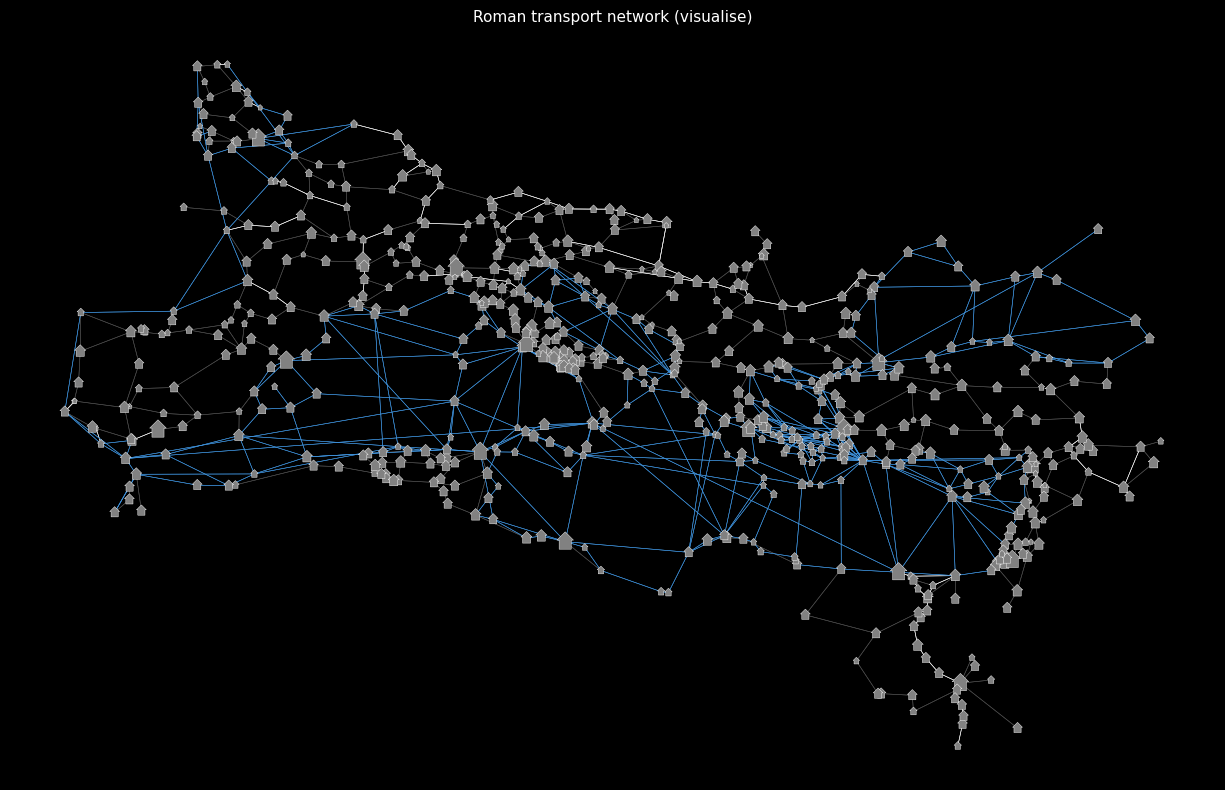

In [9]:
### equivalent to NetLogo 'visualise'
model.plot_network()

## Visualisation: provinces
Replicate NetLogo `provinces`:
- House-shaped nodes coloured by Roman province using exact NetLogo colour values.
- Settlements with an unrecognised or missing province are drawn in default grey.

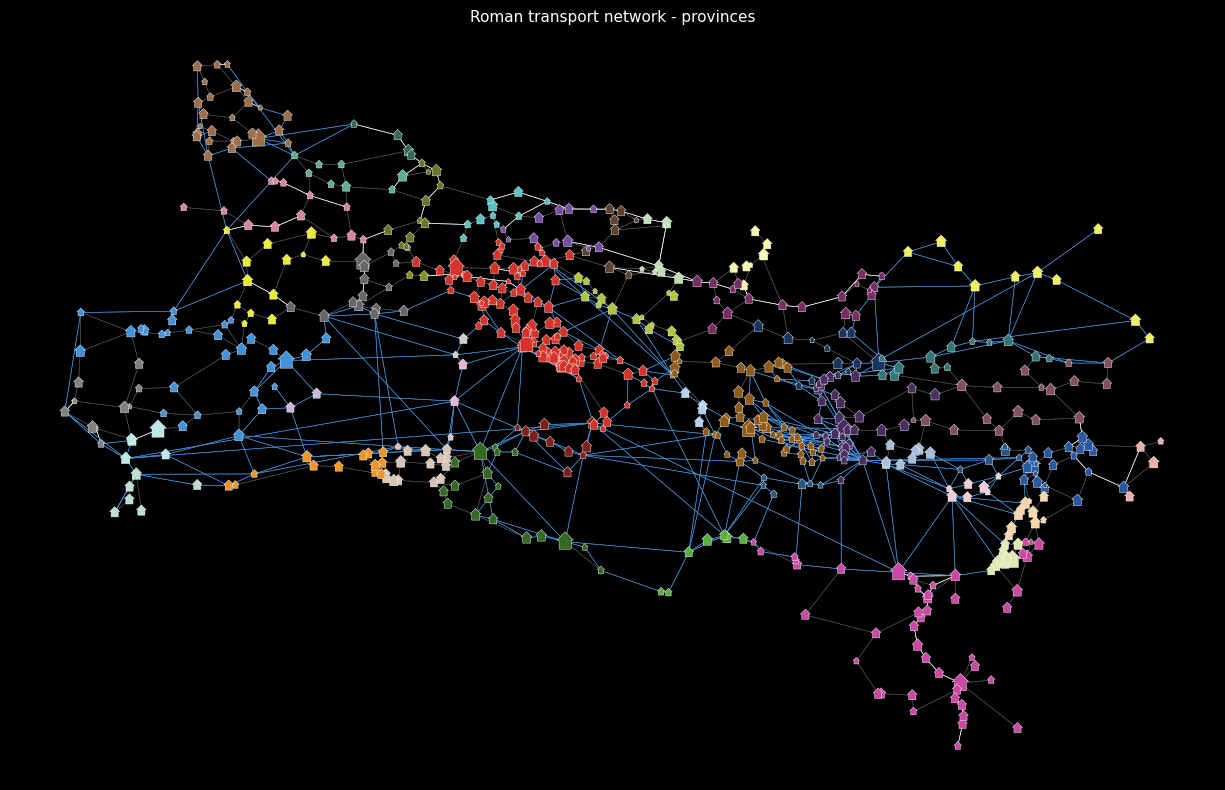

In [10]:
### equivalent to NetLogo 'provinces'
model.plot_provinces()

## Visualisation: distance maps
Replicate NetLogo `visualise-distance`: greyscale map using unweighted hop-count distances.
White = closest to Rome; black = furthest or unreachable.
Node colour uses the exact NetLogo formula: `max(0, 9.9 - (distance / max_distance) x 10)`.

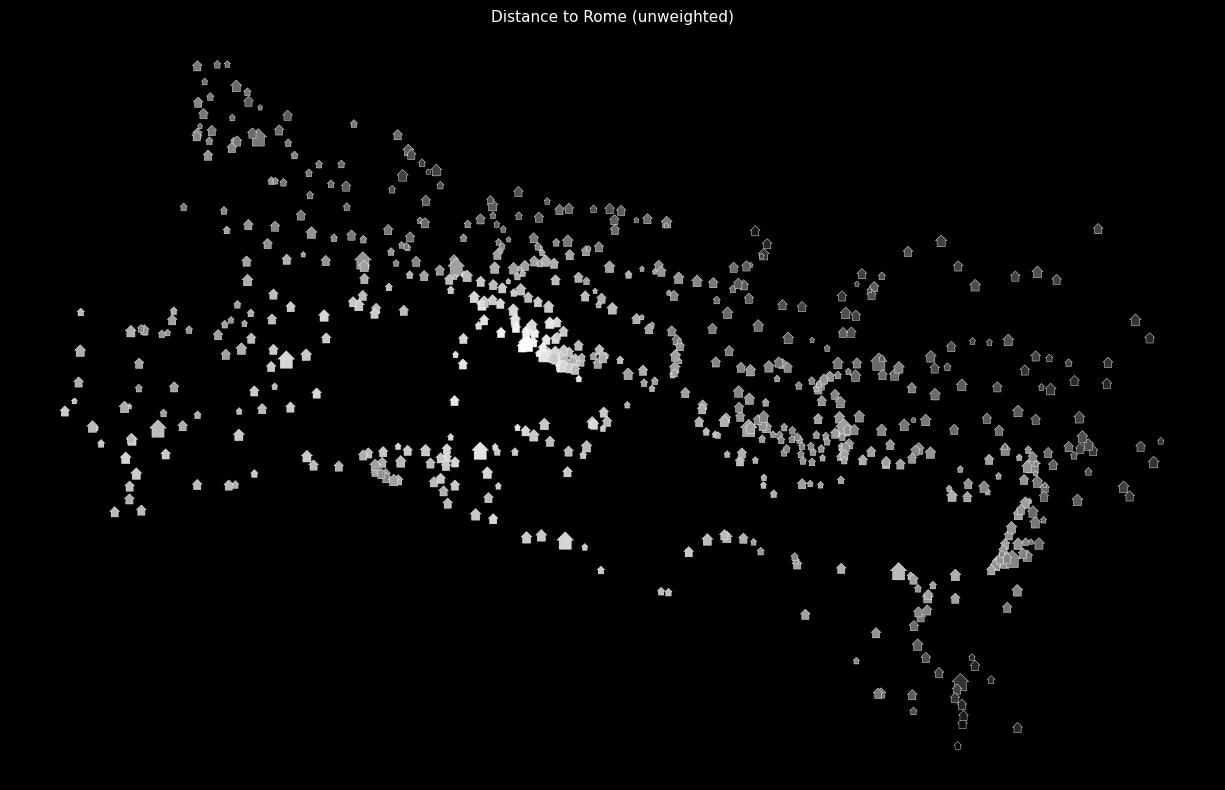

In [11]:
### equivalent to NetLogo 'visualise-distance'
model.plot_distance_map(weight_attr=None)

Replicate NetLogo `visualise-distance-km`: greyscale map using kilometre-weighted distances:

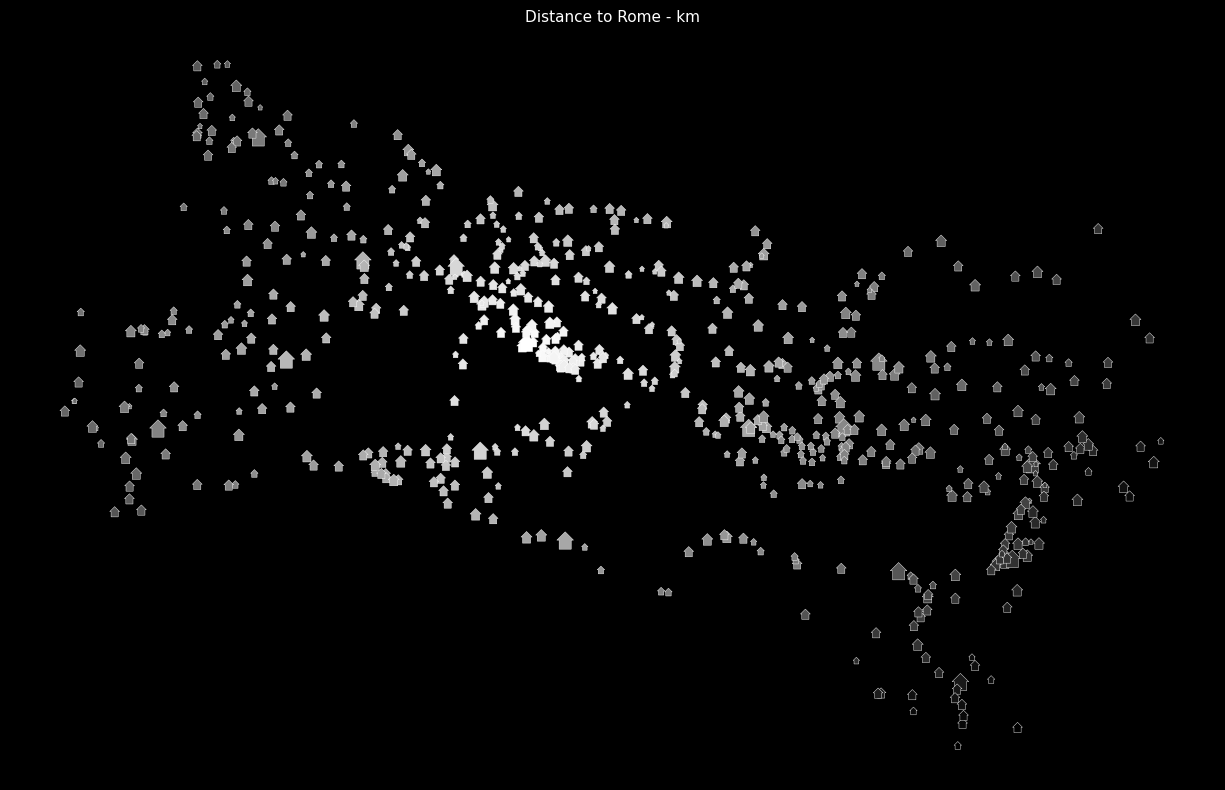

In [12]:
### equivalent to NetLogo 'visualise-distance-km'
model.plot_distance_map(weight_attr="km")

Replicate NetLogo `visualise-distance-days`: greyscale map using travel-day-weighted distances:

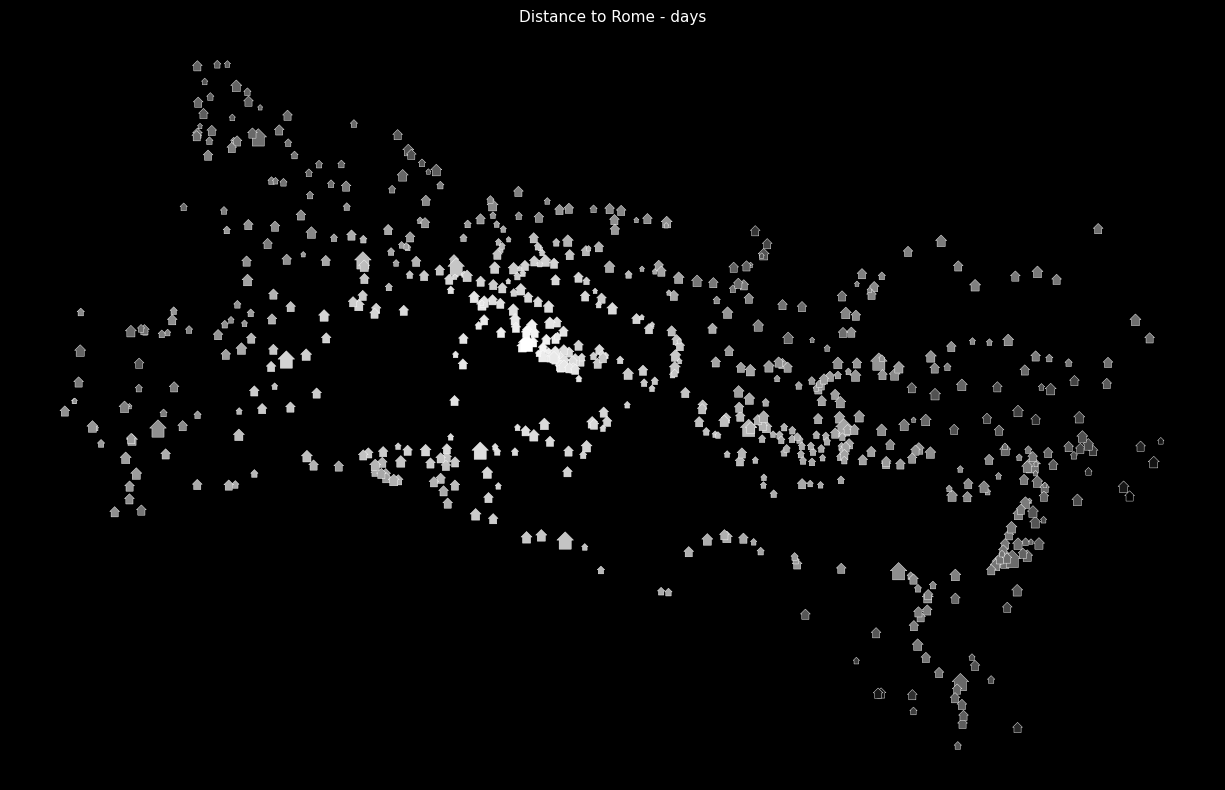

In [13]:
### equivalent to NetLogo 'visualise-distance-days'
model.plot_distance_map(weight_attr="days")

Replicate NetLogo `visualise-distance-expense`: greyscale map using cost-weighted distances:

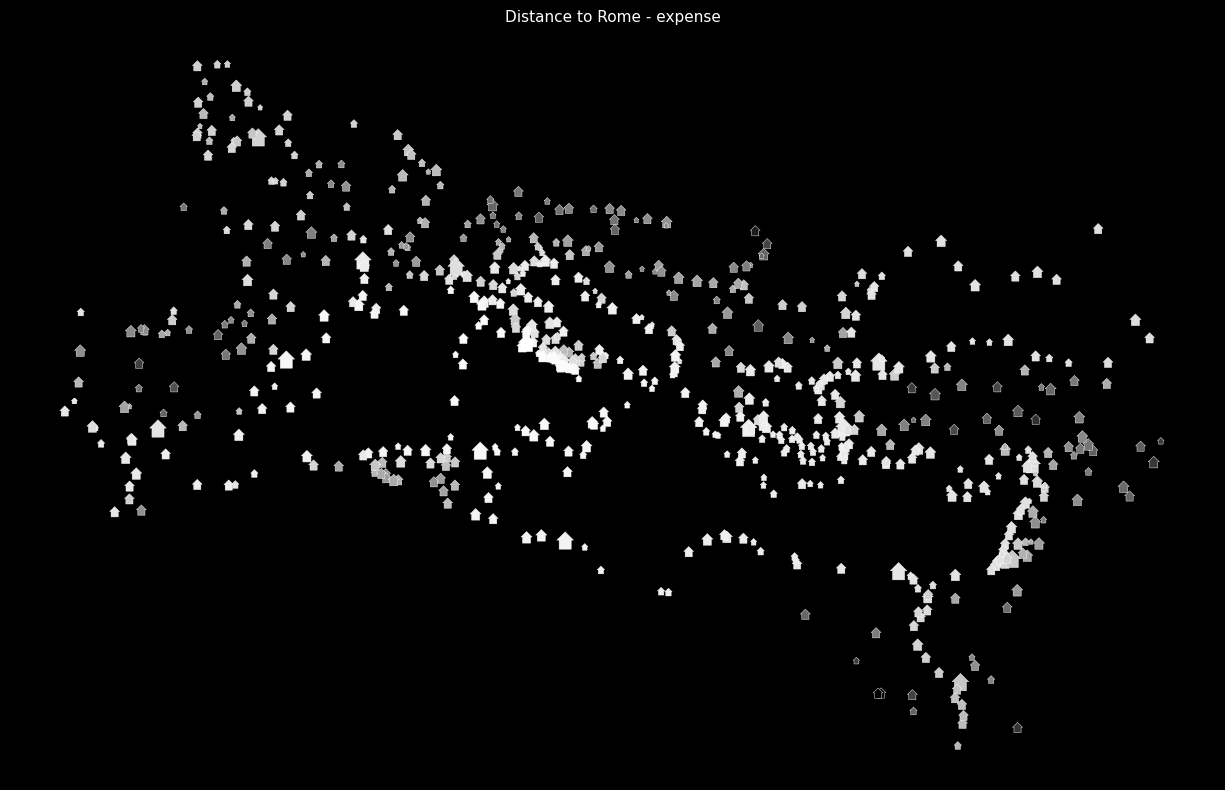

In [14]:
### equivalent to NetLogo 'visualise-distance-expense'
model.plot_distance_map(weight_attr="expense")